In [2]:
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

DB_PATH = "/Users/arnarfreyrerlingsson/Desktop/Polymarket_bitcoin_5min/db/polymarket.duckdb"

In [17]:
def query_to_df(query, limit=1000):
    HARD_LIMIT = 5_000_000
    if limit:
        limit = f"\n LIMIT {limit}"
    else:
        limit = f""
        #limit = f"\n LIMIT {HARD_LIMIT}"

    con = duckdb.connect(DB_PATH,read_only=True)
    try:
        query = str(query) + limit
        df = con.execute(query).df()
        return df
    finally:
        con.close()


def get_market_prices(market,secs_in = -1):
    df = query_to_df(f"""
        SELECT *
        FROM MARKET_TRADES
        WHERE MARKET = '{market}'
        AND SECS_INTO_WINDOW >= {secs_in}
        AND SECS_INTO_WINDOW <= 301
        ORDER BY THE_TIME ASC
        """,10000)
    start_s = min(df['THE_TIME'])
    end_s = max(df['THE_TIME'])
    strike = df['PRICE_TO_BEAT'].iloc[0]
    return start_s,end_s,strike,df

def get_btc_prices(start_s,end_s):
    query = f"""
    SELECT OPEN_TIME AS THE_TIME,OPEN AS PRICE,VOLUME,QUOTE_VOLUME,COUNT,TAKER_BUY_VOLUME,TAKER_BUY_QUOTE_VOLUME,IGNORE
    FROM bitcoin_prices
        WHERE OPEN_TIME BETWEEN TIMESTAMPTZ '{start_s}' AND TIMESTAMPTZ '{end_s}'
        ORDER BY OPEN_TIME ASC
    """
    df = query_to_df(query)
    return df

def plot_market(market,secs_in = -1,plot_btc = False):
    start_s,end_s,strike,trades_df = get_market_prices(market = market,secs_in = secs_in)
    btc_df = get_btc_prices(start_s,end_s)

    down_trades = trades_df[trades_df['OUTCOME'] == 'Down']
    up_trades = trades_df[trades_df['OUTCOME'] == 'Up']

    xlim_plot = [min(down_trades['THE_TIME']),max(down_trades['THE_TIME'])]
    fig,(ax1,ax2) = plt.subplots(2,1,figsize = (14,8))
    ax1.plot(up_trades['THE_TIME'],up_trades['PRICE']*100,color = 'limegreen',label = 'Price Up',alpha = 0.7)
    ax1.plot(down_trades['THE_TIME'],down_trades['PRICE']*100,color='crimson',label = 'Price Down',alpha = 0.7)


    ax1.set_ylabel("Cents")
    ax1.set_xlim(xlim_plot)
    ax1.set_title(f"MARKET – {MARKET}")


    ax2.plot(btc_df['THE_TIME'], btc_df['PRICE'], color='steelblue', label="Binance BTC Price",alpha = 0.7)
    ax2.plot(btc_df['THE_TIME'],strike*np.ones(np.size(btc_df['THE_TIME'])),'--',label = 'Strike')
    ax2.set_ylabel("BTC Price USD")
    ax2.set_xlim(xlim_plot)
    ax2.legend()
    ax2.set_title("Binance Bitcoin price")


    ax3 = ax1.twinx()

    if plot_btc:
        ax3.plot(btc_df['THE_TIME'],strike*np.ones(np.size(btc_df['THE_TIME'])),'--',label = 'Strike')
        ax3.plot(btc_df['THE_TIME'], btc_df['PRICE'], color='steelblue', label="Binance BTC Price",alpha = 0.7)
        ax3.set_ylabel("BTC Price USD")
        ax3.tick_params(axis="y")
        max_dev = (btc_df['PRICE'] - strike).abs().max()
        pad = max_dev * 0.1 or 1
        ax3.set_ylim(strike - max_dev - pad, strike + max_dev + pad)

    lines = ax1.get_lines() + ax2.get_lines()
    ax1.legend(lines, [l.get_label() for l in lines])

    plt.show()

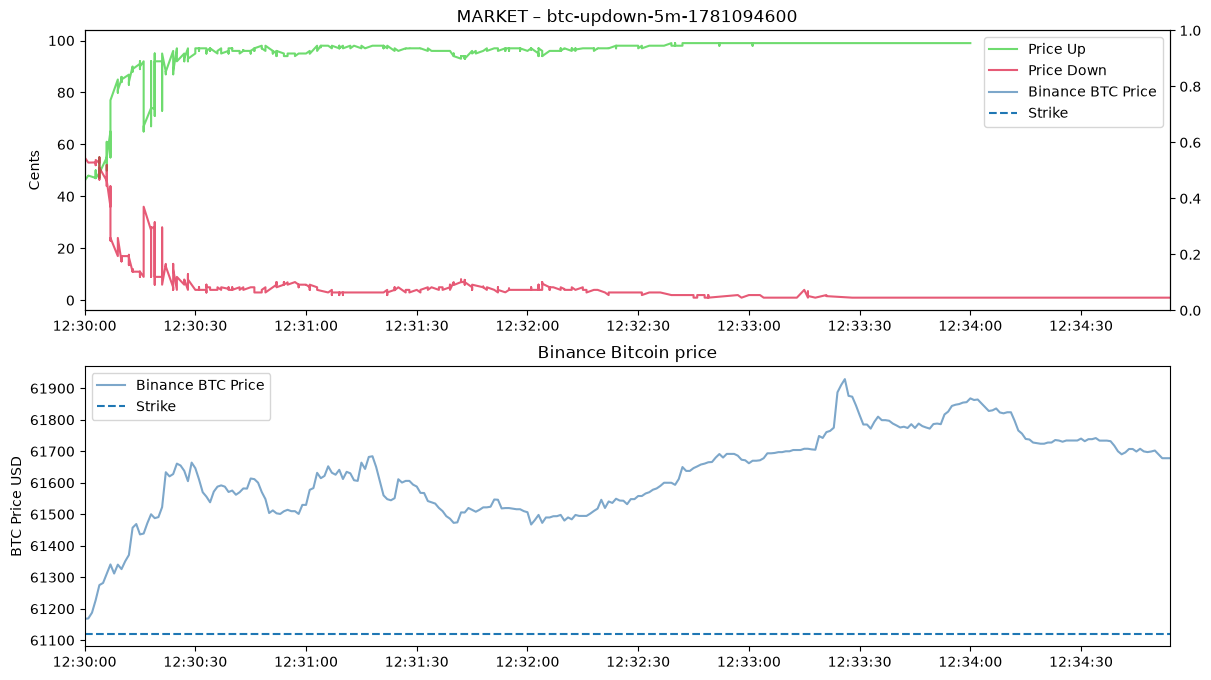

In [18]:
MARKET = 'btc-updown-5m-1781094600'
plot_market(MARKET,plot_btc=False)